In [1]:
# dependencies
import numpy as np
import matplotlib.pyplot as plt
# conversion factors
a0 = 5.29e-11 # Bohr radius in m
Eh = 4.36e-18 # Hartree energy in J
me = 9.109e-31 # electron mass in kg
mp = 1.673e-27 # proton mass in kg
uma = 1.66e-27 # atomic mass unit in kg
mass_factor = mp/me # mass factor to convert from uma to me

## SIMULATING THE CANONICAL ENSEMBLE BEYOND THE HARMONIC OSCILLATOR MODEL

In the previous lab, we derived the formalism required to simulate a system in the canonical ensemble using Langevin dynamics.
In this session, we will extend that approach to explore more complex systems, where a simple harmonic oscillator is no longer sufficient to describe the desired potential energy function.


Consider an isoenergetic reaction where reactants and products have the same energy. A real example of this can be the reaction between clorine and cloromethane: $CCl_{4} + Cl^{-} -> CCl4 + Cl-$, the exchange of a acid proton $HA + H^{+} -> HA + H^{+}$ or in a more relevant case: the conformational change of a cyclohexane

<img src="1200px-Ring_flip.png">

Since cyclohexane does not have substituents both chair conformation have the same energy. The potential energy surface can be described as a function of a single dihedral angle. A simple model for this potential is given by the double well potential:
$V(x) = a(x^{2} - b^{2})^{2}$
where a and b are parameters that control certain features of the potential's shape.

The double well potential is already implement in ToyMD as a 1D-potential

In [ ]:
#load modules
from potentials import *
from walker import Trajectory1D

In [463]:
pot = create_potential("Doublewell", a=10e10, b=350*a0) # create potential object with the parameters a and b

In [464]:
# create trajectory object with Langevin integrator at T=10K
traj = Trajectory1D(potential=pot, m=10*uma, dt=1e-12, steps=100000, x0=0*a0, v0=0.0, integrator="langevin", gamma=1.0e12, T=10)

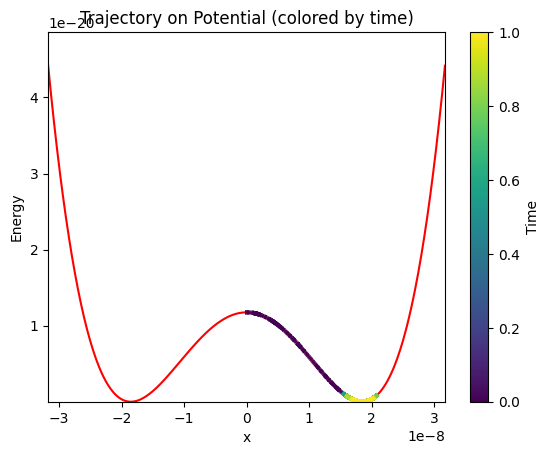

In [465]:
#Run the dynamic and analyze the plots
traj.run()
traj.plot_on_potential(xmin=-600*a0, xmax=600.0*a0)

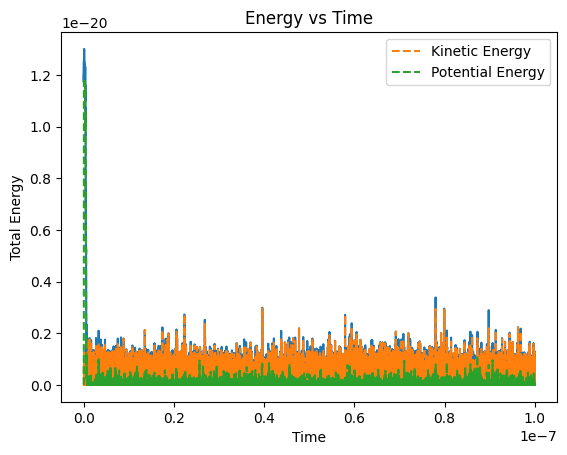

In [444]:
traj.plot_energy()

## HANDS-ON ACTIVITY

- Evaluate the phase space sampled if the system start from one of the minima
- How can you increase the phase space sampled ? 

## case 2: the Asimmetric double well potential

A more attractive 1D model to simulate is the assimetric double well potential, since this surface present two minima at different level of potential energy connected by a local maximum, that in principle can represent Endothermal and Exothermal reactions

From a mathematical point of view this potential can be builded from the simmetric potential plus an extra term depending of x

$V(x) = a (x^{2} - b^{2})^{2} + cx$

In [467]:
pot2 = create_potential("AsimmetricDoublewell", a=10e10, b=350*a0, c=10e7*a0**2) # create potential object

In [468]:
traj = Trajectory1D(potential=pot2, m=10*uma, dt=1e-12, steps=100000, x0=0*a0, v0=0.0, integrator="langevin", gamma=1.0e12, T=10)

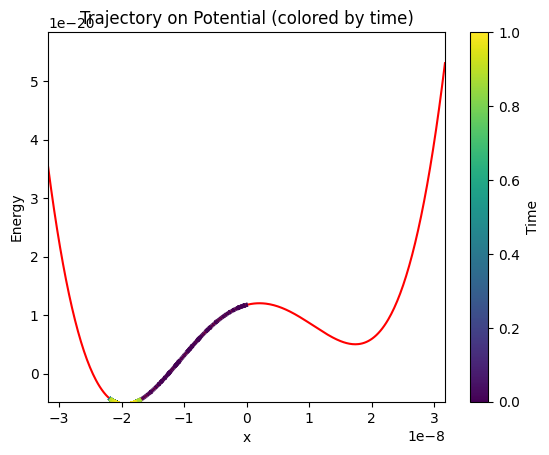

In [469]:
#Run the dynamic and analyze the plots
traj.run()
traj.plot_on_potential(xmin=-600*a0, xmax=600.0*a0)

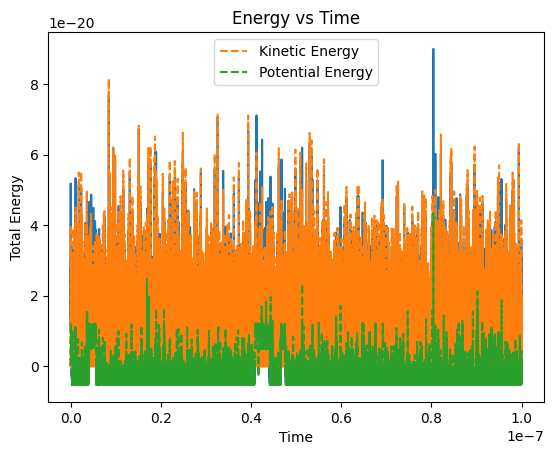

In [461]:
traj.plot_energy()

## Hands-On Activity  
### Case 2: The Asymmetric Double Well Potential

- **act 1:** Start the simulation in the **left well** and analyze the resulting dynamics.  
- **act 2:** Repeat the simulation, this time starting from the **right well**, and **compare** both cases.  
- **act 3:** **Evaluate** how the **parameter `c`** affects:
  - The **shape** of the potential (asymmetry, depth of wells, barrier height).
  - The **dynamics** of the system (stability, oscillations, transitions).  
- **act 4:** **Estimate the rate constant** for transitions between both wells. 
- **act 5:** **Identify real systems** that could be modeled by an asymmetric double well potential. 